Train shape: (56, 6)
Validation shape: (12, 6)
Test shape: (12, 6)


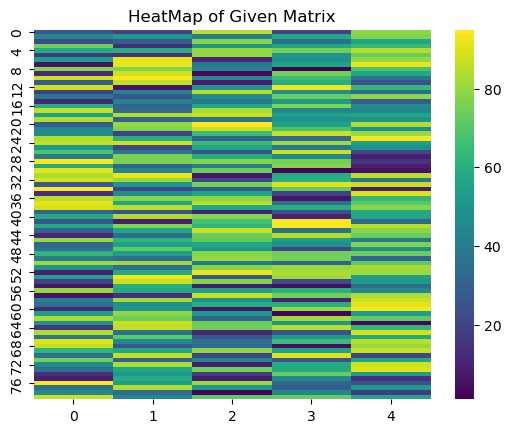

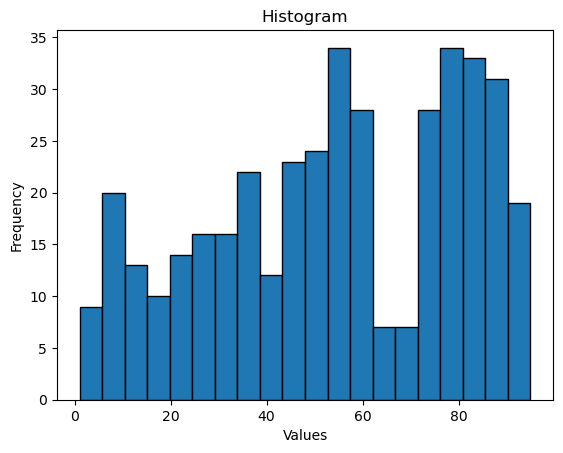

(80, 5)
---------------------Eigen Vectors------------------ 


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
matrix=[]
for i in range(80):
    row=[]
    for j in range(5):
        random_int=np.random.randint(1,4)
        if random_int == 1:
            val=np.random.uniform(1,40)
            
        elif random_int == 2:
          values = np.arange(41, 71)
          mean = np.mean(values)
          variance = np.mean((values - mean) ** 2)
          std = np.sqrt(variance)
          val = np.random.normal(loc=mean, scale=std)

            
        else:
            lam = (71+95)/2
            val = np.random.poisson(lam)
            while val < 71 or val > 95:
                val = np.random.poisson(lam)

        row.append(int(val))
    matrix.append(row) 

# for row in matrix:
#     print(*row) 
    
row=[3.1,4.5,5.1,6.5,6]
matrix2=[]
for i in range(80):
    r1=[]
    for j in range(5):
        
        y=row[j]*matrix[i][j]
        r1.append(y)
    matrix2.append(r1)
per=[]
for i in range(80):
    sum=0
    for j in range(5):
         sum += matrix2[i][j]
    sum += np.random.randint(0,2) 
    per.append(sum)

# for value in per:
#     print(value) 

# Add perceptron output as 6th column
per = np.array(per).reshape(80,1)
dataset = np.hstack((matrix, per))
# print("Dataset with perceptron output (6th column):")
# print(dataset)
# print("Shape:", dataset.shape)       

# ----------------------------
# Step 4: Split dataset into Train/Validation/Test
# ----------------------------

# Shuffle the data first
np.random.seed(42)  # for reproducibility
np.random.shuffle(dataset)

total_rows = dataset.shape[0]
train_end = int(0.7 * total_rows)  # first 70%
val_end = int(0.85 * total_rows)   # next 15%

# Split
train_data = dataset[:train_end]
val_data = dataset[train_end:val_end]
test_data = dataset[val_end:]

print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

#Heatmap of the matrix

#plt.figure(figsize=(8,6))   
sns.heatmap(matrix, fmt="d", cmap='viridis')
plt.title("HeatMap of Given Matrix")
plt.show()

#Histogram of the matrix
matrix=np.array(matrix) 
flattened_data=matrix.flatten()
#count, bin_edges=np.histogram(flattened_data,bins=20)
plt.hist(flattened_data, bins=20, edgecolor='black')
plt.title("Histogram")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show() 

#Step 1: Standardization
mean = np.mean(matrix, axis=0)
std = np.std(matrix, axis=0, ddof=1)
Z = (matrix - mean) / std
print(Z.shape)

#Step 2: Calculate Co Variance matrix
cov_matrix = np.cov(Z, rowvar=False)
cov_matrix_2dp = np.round(cov_matrix, 2)
# print("---------------------Covariance Matrix------------------ ")
# print(cov_matrix_2dp)
    

#Step 3: Calculate Eigen Values & Eigen Vectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues_2dp = np.round(eigenvalues, 2)
# print("---------------------Eigen Values------------------ ")
# print(eigenvalues_2dp)

print("---------------------Eigen Vectors------------------ ")
eigenvectors_2dp = np.round(eigenvectors, 2)
# print(eigenvectors_2dp)


PC = np.dot(Z, eigenvectors)
# print("Principal Components:")
# print(PC)




            
   

        
